In [1]:
import importlib
import sys

# Add current directory to sys.path (if not already)
if '.' not in sys.path:
    sys.path.append('.')

# Import the module the first time
import environments

# Reload it to pick up changes
importlib.reload(environments)

# Now import the classes/functions you need
from environments import StockPortfolioEnv, StockPriceSimulator


In [2]:
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
import numpy as np
from environments import StockPortfolioEnv, StockPriceSimulator  # assuming you've saved the code as environments.py
from generators import LinearTrendPriceGenerator, CashPriceGenerator, PeriodicTrendPriceGenerator
# Define initial prices for stocks
initial_prices = {"UPWARD": 505, "CASH": 500}

# Define different price behaviors for each stock
generators = {
"UPWARD": LinearTrendPriceGenerator(start_price=505, up = False), #PeriodicTrendPriceGenerator(start=500, amplitude=-50, frequency=0.15),
"CASH": CashPriceGenerator()  # Cash remains constant
}


# Create the simulator
simulator = StockPriceSimulator(days=500, initial_prices=initial_prices, generators=generators)

# Generate stock prices
df = simulator.generate_prices()
df.head()

from stable_baselines3.common.vec_env import DummyVecEnv
# Replace this with your own environment class and setup
def make_env():
    return StockPortfolioEnv(
        df=df,
        stock_dim=2,
        initial_amount=100,
        state_space=12,
        action_space=2
    )

# Create vectorized environment
env = DummyVecEnv([make_env])

# Action noise for TD3 (helps with exploration)
n_actions = 2
action_noise = NormalActionNoise(mean=np.zeros(n_actions), sigma=0.1 * np.ones(n_actions))

# Create and train the TD3 model
model = TD3("MlpPolicy", env, learning_rate=6.06e-05,
    gamma=0.941,
    batch_size=64, action_noise=action_noise, verbose=1)
model.learn(total_timesteps=10_000)
model.save("td3_stock_alloc")


/opt/anaconda3/envs/rl_project/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Using cpu device
EPISODE:  0
raw actions  [0.5, 0.5]
weights:  [0.5 0.5]
reward -0.5
raw actions  [0.7607951 0.909081 ]
weights:  [0.45559973 0.5444003 ]
reward -0.5444002747535706
raw actions  [0.22834688 0.3105762 ]
weights:  [0.4237096 0.5762904]
reward -0.5762904286384583
raw actions  [0.71335196 0.06910762]
weights:  [0.91167897 0.08832101]
reward -0.0883210077881813
raw actions  [0.7654296 0.7328422]
weights:  [0.510875 0.489125]
reward -0.48912501335144043
raw actions  [0.6495241  0.28719336]
weights:  [0.6934045 0.3065955]
reward -0.30659550428390503
raw actions  [0.19504675 0.1700117 ]
weights:  [0.5342891 0.4657109]
reward -0.46571090817451477
raw actions  [0.13707006 0.57519376]
weights:  [0.19244282 0.80755717]
reward -0.8075571656227112
raw actions  [0.13800314 0.84207976]
weights:  [0.14080763 0.85919243]
reward -0.859192430973053
raw actions  [0.34304368 0.5646297 ]
weights:  [0.37793738 0.6220626 ]
reward -0.622062623500824
raw actions  [1.         0.55321723]
weights: 

In [3]:
env.get_attr("save_episode_log")[0]("episode_log.csv")


Saved episode log to episode_log.csv


In [4]:
import pandas as pd
episode_log = pd.read_csv("episode_log.csv")

In [5]:
last_allocs = episode_log.groupby("episode").tail(1)[["episode", "allocation_weights"]]
last_allocs

,episode,allocation_weights
493,0,"0.03, 0.97"
987,1,"0.08, 0.92"
1481,2,"0.00, 1.00"
1975,3,"0.00, 1.00"
2469,4,"0.00, 1.00"
2963,5,"0.00, 1.00"
3457,6,"0.10, 0.90"
3951,7,"0.01, 0.99"
4445,8,"0.02, 0.98"
4939,9,"0.00, 1.00"


In [6]:
upward_prices = df[df['tic'] == 'UPWARD']['close'].reset_index(drop=True).iloc[1:].reset_index(drop=True)
upward_prices

0      494
1      493
2      492
3      491
4      490
      ... 
489      5
490      4
491      3
492      2
493      1
Name: close, Length: 494, dtype: int64

In [7]:
 episode_log.loc[episode_log['episode'] == 19, 'allocation_weights']

9386    0.50, 0.50
9387    0.00, 1.00
9388    0.00, 1.00
9389    0.00, 1.00
9390    0.00, 1.00
           ...    
9875    0.00, 1.00
9876    0.04, 0.96
9877    0.00, 1.00
9878    0.10, 0.90
9879    0.00, 1.00
Name: allocation_weights, Length: 494, dtype: object

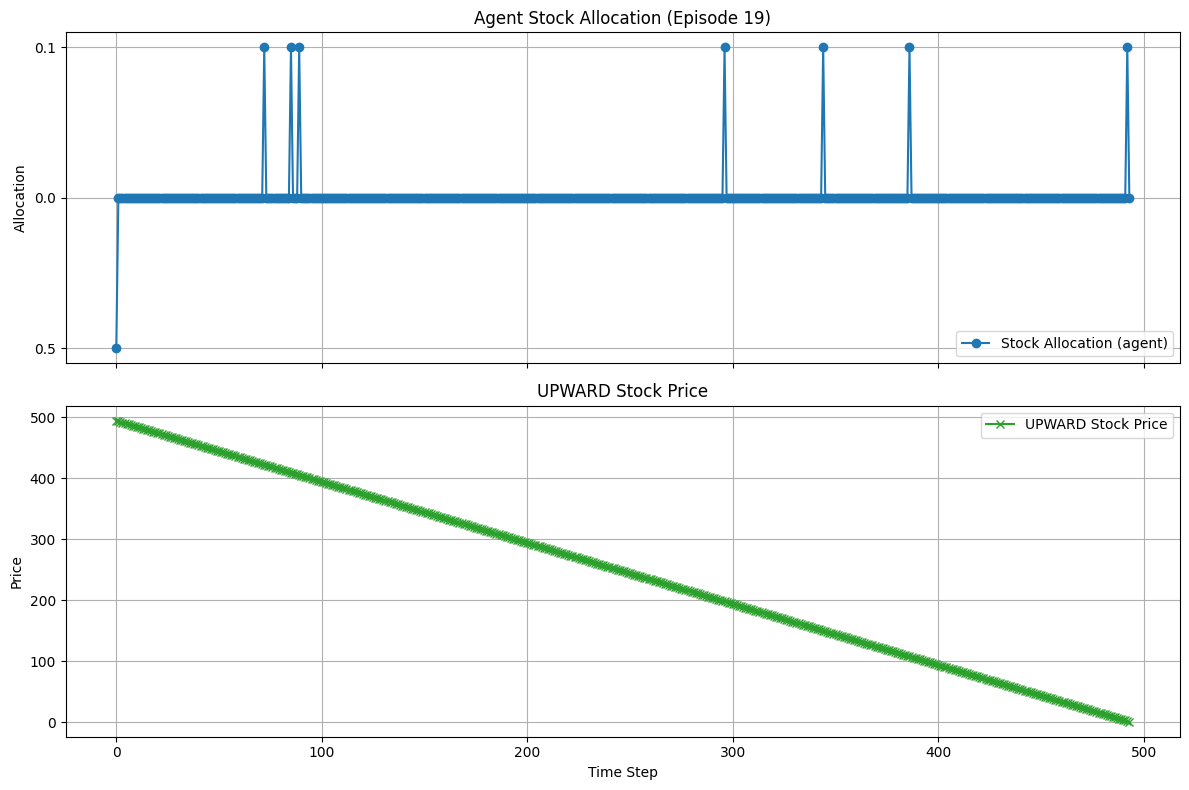

In [8]:
upward_prices = df[df['tic'] == 'UPWARD']['close'].reset_index(drop=True).iloc[1:].reset_index(drop=True)

import matplotlib.pyplot as plt


alloc = episode_log.loc[episode_log['episode'] == 19, 'allocation_weights'].apply(lambda x: x[:3]).reset_index(drop=True)


# 2. Plot in two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot stock allocation
ax1.plot(alloc.values, label='Stock Allocation (agent)', marker='o', color='tab:blue')
ax1.set_ylabel('Allocation')
ax1.set_title('Agent Stock Allocation (Episode 19)')
ax1.grid(True)
ax1.legend()

# Plot UPWARD stock price
ax2.plot(upward_prices.values, label='UPWARD Stock Price', marker='x', color='tab:green')
ax2.set_ylabel('Price')
ax2.set_title('UPWARD Stock Price')
ax2.set_xlabel('Time Step')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.td3 import TD3
from stable_baselines3.common.evaluation import evaluate_policy
import optuna

def make_env():
    return StockPortfolioEnv(
        df=df,
        stock_dim=2,               # Adjust if needed
        initial_amount=100_000,
        state_space=12*2,            # Example: 6 features × 2 stocks
        action_space=2             # One per stock
    )


def objective(trial):
    env = DummyVecEnv([make_env])
    action_noise = NormalActionNoise(mean=np.zeros(2), sigma=0.1 * np.ones(2))

    model = TD3(
        "MlpPolicy", env,
        learning_rate = trial.suggest_float("lr", 1e-5, 1e-3, log=True),
        gamma = trial.suggest_float("gamma", 0.9, 0.999),
        batch_size=trial.suggest_categorical("batch_size", [64, 128]),
        action_noise=action_noise,
        verbose=0
    )
    
    model.learn(total_timesteps=5000)
    mean_reward, _ = evaluate_policy(model, env, n_eval_episodes=1)
    return mean_reward

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best hyperparameters:", study.best_params)


In [3]:
from finrl.agents.stablebaselines3.models import DRLAgent

In [8]:
# Initialize environment
env = StockPortfolioEnv(
    df=df,
    stock_dim=2,
    initial_amount=100000,
    state_space=1,
    action_space=2
)

# Wrap for Stable-Baselines
from stable_baselines3.common.vec_env import DummyVecEnv
env = DummyVecEnv([lambda: env])


/opt/anaconda3/envs/rl_project/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


In [15]:
# initialize the agent
agent = DRLAgent(env = env)
DDPG_PARAMS = {"batch_size": 128, "buffer_size": 50000, "learning_rate": 0.001}
model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_PARAMS)

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001}
Using cpu device


In [16]:
episodes = 5
days = 500 
trained_ddpg = agent.train_model(model=model_ddpg,tb_log_name='ddpg',total_timesteps=episodes*days)

EPISODE:  17
raw weights  [0.5 0.5]
raw actions:  [0.5, 0.5]
raw weights  [0.476305 0.523695]
raw actions:  [0.86500025 0.9510635 ]
raw weights  [0.26234385 0.7376561 ]
raw actions:  [0.31946588 0.89827126]
raw weights  [0.7676348  0.23236519]
raw actions:  [0.62804246 0.1901102 ]
raw weights  [0.94210607 0.05789395]
raw actions:  [0.8307994  0.05105397]
raw weights  [0.50508755 0.49491245]
raw actions:  [0.23349816 0.22879428]
raw weights  [0.23215352 0.76784647]
raw actions:  [0.26848274 0.8880052 ]
raw weights  [0.5579897  0.44201028]
raw actions:  [0.22464556 0.17795247]
raw weights  [0.1146117 0.8853883]
raw actions:  [0.09773338 0.75500137]
raw weights  [0.56523776 0.43476215]
raw actions:  [0.6967017  0.53587985]
raw weights  [0.8052363  0.19476369]
raw actions:  [0.95687425 0.2314406 ]
raw weights  [0.6344006  0.36559936]
raw actions:  [0.33990887 0.19588643]
raw weights  [0.24124907 0.7587509 ]
raw actions:  [0.20302188 0.63852286]
raw weights  [0.4067266  0.59327334]
raw acti